# U.C. Berkeley Engineering Capstone Project 

* Charles David Harris
* davidharrisne@gmail.com

## Predicting Progression to Alzheimer's Disease from Blood Protein Levels

1. [Abstract](#abstract)
2. [CRISP-DM methodology:](#methodology)
    
    1. [Business Understanding](#business-understanding)
    2. [Data Understanding](#data-understanding)
    3. [Data Preparation](#data-preparation)
    4. [Modeling](#modeling)
    5. [Evaluation](#evaluation)
    6. [Conclusion](#conclusion)

3. [Future Work](#future-work)
4.  [References](#references)

<a id="abstract"></a>
# 1. Abstract

This project explored a Kaggle dataset to test the hypothesis that Amyloid and Tau protein levels are predictive of developing alzhiemers in the future.
 [Kaggle Plasma lipidomics in Alzheimer's disease](https://www.kaggle.com/datasets/fereshtehjozaghkar/plasma-lipidomics-in-alzheimers-disease)

**Description**
"This dataset contains 213 plasma samples, including 20 controls, 89 samples from individuals with mild cognitive impairment, and 104 samples from individuals with Alzheimer's disease. Furthermore, the dataset includes information on age, sex, cognitive evaluation results, and cerebrospinal fluid biomarkers indicative of Alzheimer's disease."

For this work, F2, was chosen as the metric to look for. F2 is a balance between precission and recall placing twice the weight of recall as precision. **F2** answers: weighing precision and recall together, but caring more about recall. It has a focus on false negatives while penalizing mised diagnosis - false positives. 

$$F_2 = 5 \times \frac{\text{precision} \times \text{recall}}{4 \times \text{precision} + \text{recall}}$$


**This test was approached from two approaches:**
 1. Parameter Pipeline

 This notebook uses an exhaustive search to evalute parameters with StratifiedKFold, Logistic Regression.  Results were sorted by F2. The results with'CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)' showed an F2 and Recall of 0.80. Hypertuning using GridSearchCV produced the parameters LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000) which resulted in slightly higher Accuracy, and a stable Recall and F2 of 0.800. The False Negatives showed the most improvement from 8 to 2.

[Logisticregression](logistic_regression_pipeline.ipynb) 

2. Classificaiton Pipeline

This notebook used a set of models with default parameters to derive the best classification algorithm given all the 
parameters 	Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),	CSF Phosphorylated tau (pg/mL),	Sex,APOE4
Sorting by F2, presented KNeighborsClassifier as the top choice.Then GridSearchCV was used to derive the optimal paramters. 
[KNearestNeighbors](knearest_neighbors_pipeline.ipynb)


<a id="methodology"></a>
# 2. CRISP_DM Methodology

<a id="business-understanding"></a>
##  A. Business Understanding

### Alzhiemer's Disease Epidemic

Worlwide, there are greater than 55 million living with Alzheimer's Disease , and baring medical breakthroughs, this number will double every 20 years[1]. Alzhiem's Disease is characterized by neuron death and brain tissue damage leading to irriversable dementia. Within medical research there is a consensus that two protiens found in the brain: **amyloid** and **tau** are predictors of developing alzhiemers in the future. There is excitement and active research to find ways to treat the brain's amylid plaques and tau tangles before the onset of Azheimer's.


<a id="data-understanding"></a>
##  B. Data Understanding
The following cells show the preliminary data exploration.

In [22]:
import pandas as pd
import seaborn as sns
#sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

In [24]:
import seaborn as sns

In [25]:
df = pd.read_csv("data/plasma_lipidomics.csv")

In [26]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN


In [27]:
len(df)

212

In [28]:
def histogram(label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

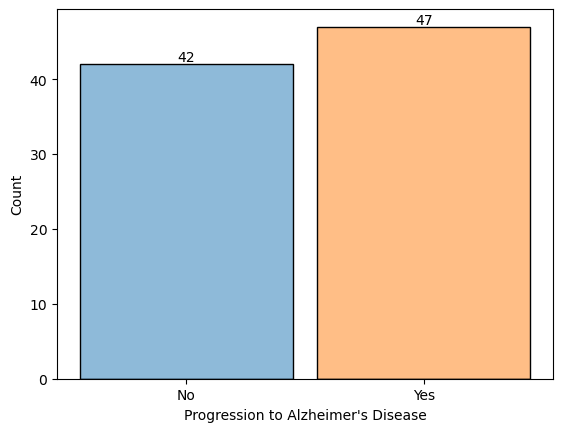

In [30]:
histogram("Progression to Alzheimer's Disease")

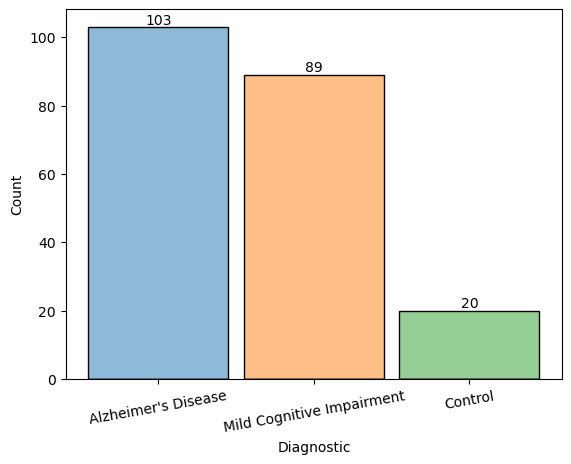

In [31]:
histogram("Diagnostic",rotation=10)

### Exploring the relationships between Diagnostic and the key indicator "Progression to Alzeimers's Disease"

In [32]:
overlap_yes = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 47
Non-MCI patients with Progression = No: 42


In [33]:
totals =[len(overlap_yes), len(overlap_no)]
totals

[47, 42]

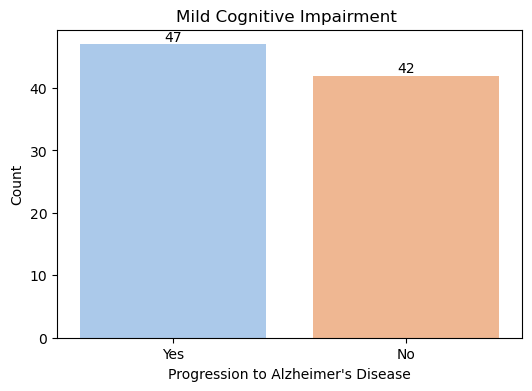

In [34]:
histogram_totals(totals=totals, title="Mild Cognitive Impairment ",xlabel="Progression to Alzheimer's Disease")

In [35]:
overlap_yes = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))


Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [36]:
df[df['Diagnostic'] == "Alzheimer's Disease"]

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99,100,Alzheimer's Disease,Female,79,19,395.0,377.0,54.8,No,NaN,NaN
100,101,Alzheimer's Disease,Female,71,28,556.0,257.0,48.1,Yes,NaN,NaN
101,102,Alzheimer's Disease,Female,70,25,354.0,312.0,53.8,Yes,NaN,NaN
102,103,Alzheimer's Disease,Male,79,25,755.0,685.0,86.3,No,NaN,NaN


In [37]:
overlap_yes = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


### Key Observation


There are no patients who's Diagnostic is 'Alzheimer's Disease' or 'Control' "Progression to Alzheimer's Disease"

Therefore are two we will only consider Diagnostic "Mild Cognitive Impairment" and "Progression to Alzheimer's Disease" Yes or No

### Data Exporation

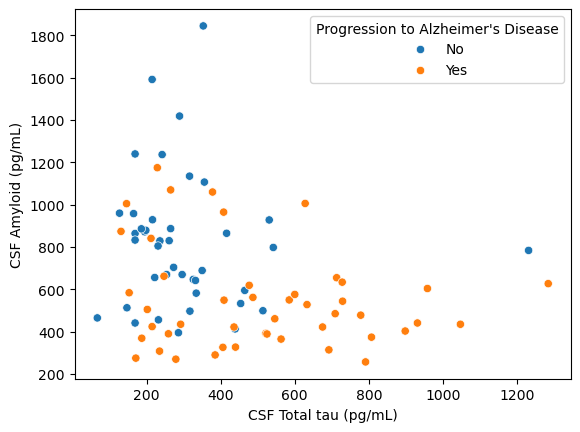

In [38]:

sns.scatterplot(data = df, x='CSF Total tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/total_tau", dpi=300, bbox_inches="tight")
plt.show()

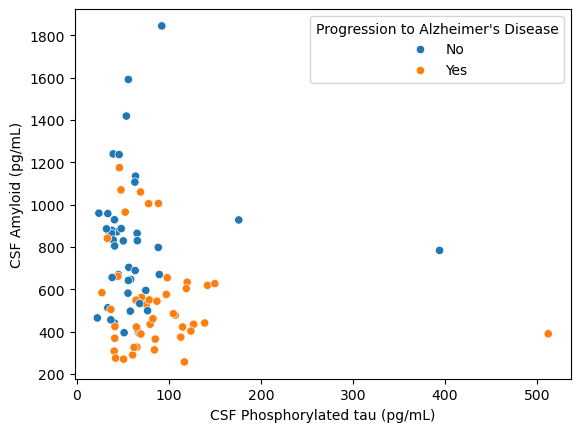

In [39]:

sns.scatterplot(data = df, x='CSF Phosphorylated tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/amyloid_tau", dpi=300, bbox_inches="tight")
plt.show()

We are going to look at the Mayo Clinic's hypothesis, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL). Testing each value with the same metric - StandardScaler/LogistitRegression, and once the best parameters are determined, we pick the best classifier method.

<img src="images/decision_boundary.png" alt="Decision boundary between progression and no progression, tau vs. amyloid" width="500">



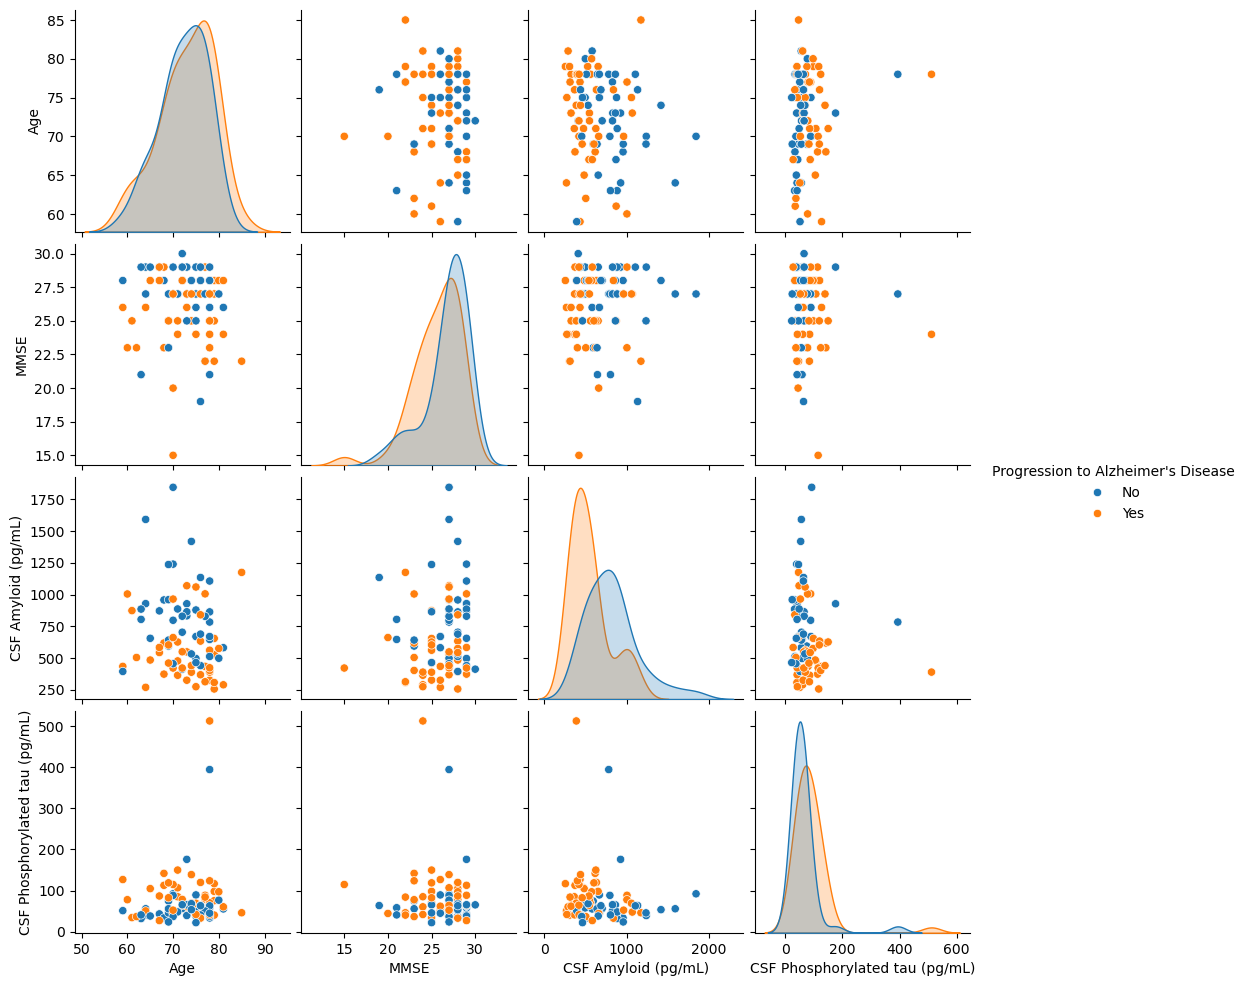

In [40]:
sns.pairplot(df[['Age','MMSE','CSF Amyloid (pg/mL)','CSF Phosphorylated tau (pg/mL)',"Progression to Alzheimer's Disease"]], hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/pair_plot", dpi=300, bbox_inches="tight")

<a id="data-preparation"></a>
## C. Data Preparation
* Preprocessing cleaning
* Each of the juyter notebooks begin with the following steps.

In [41]:

#Load the data
import pandas as pd
df = pd.read_csv('data/plasma_lipidomics.csv')
#Only use patients with a value in the "Progression to Alzheimer's Disease" column
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()
#Isolate the numeric columns
numeric_cols = ['CSF Amyloid (pg/mL)','CSF Phosphorylated tau (pg/mL)']
# Fill nan values with the median value of the column
for col in numeric_cols:
    median_val = mci[col].median()
    df[col] = df[col].fillna(median_val)
#APOE4 is a "Yes" or "No" value

df['Target'] = (df["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
# Create the featuer set by appending numeric cols with Sex and APOE4


The cleaned data can now display a view of the 'CSF Phosphorylated tau (pg/mL)', 'CSF Amyloid (pg/mL)' decision map.

/home/fazuskazoo/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


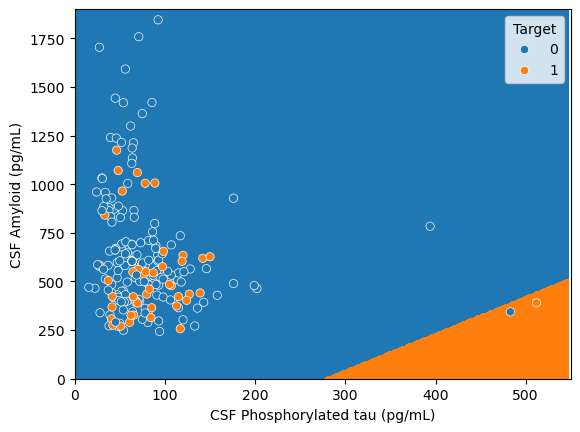

In [42]:
from matplotlib.colors import ListedColormap
logistic_regression_model = LogisticRegression()
logistic_regression_model = logistic_regression_model.fit(df[['CSF Phosphorylated tau (pg/mL)', 'CSF Amyloid (pg/mL)']], df["Target"])


sns_cmap = ListedColormap(np.array(sns.color_palette())[0:2, :])

xx, yy = np.meshgrid(np.arange(0, 550, 2),
                     np.arange(0, 1900, 5))


Z_string = logistic_regression_model.predict(np.c_[xx.ravel(), yy.ravel()])
categories, Z_int = np.unique(Z_string, return_inverse=True)
Z_int = Z_int 
Z_int = Z_int.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z_int, cmap=sns_cmap)
sns.scatterplot(data = df, x = 'CSF Phosphorylated tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Target")
plt.xlim(0, 550);
plt.ylim(0, 1900);
plt.savefig(f"images/decision_boundary", dpi=300, bbox_inches="tight")


<a id="modeling"></a>
## D. Modeling
Two independent training approaches were tried on this data:

#### 1. Parameter First


This notebook uses an exhaustive search to evalute parameters with StratifiedKFold, Logistic Regression.  Results were sorted by F2. The results with'CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)' showed an F2 and Recall of 0.80. Hypertuning using GridSearchCV produced the parameters LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000) which resulted in slightly higher Accuracy, and a stable Recall and F2 of 0.800. The False Negatives showed the most improvement from 8 to 2.

View and run the pipeline here: [Logisticregression](logistic_regression_pipeline.ipynb) 

#### 2. Classification First



This notebook used a set of models with default parameters to derive the best classification algorithm given all the 
parameters 	Age,MMSE,	CSF Amyloid (pg/mL),	CSF Total tau (pg/mL),	CSF Phosphorylated tau (pg/mL),	Sex,	APOE4

```
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)':            Pipeline([('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':  Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'LDA':                  Pipeline([('sc', StandardScaler()), ('clf', LinearDiscriminantAnalysis())]),
    'Naive Bayes':          Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())]),
}
```


View and run the pipeline here: [knearest_neighbors_pipeline](knearest_neighbors_pipeline.ipynb#coefficients)




<a id="evaluation"></a>
## E. Evalution

#### 1. Parameter First

```
Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
```
|Accuracy|Precision| ROC_UAC | Recall | F2 |False Negatives | False Negative Rate|
|--|--|--|--|--|--|--|
|0.73|0.70|0.78| 0.82 |  0.80 | 0.80 | 0.17|

```
 Pipeline([('sc', StandardScaler()),('clf', LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000))])
```

#### 2. Classification First
```
Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())])
```
|Accuracy|Precision| ROC_UAC | Recall | F2 |False Negatives | False Negative Rate|
|--|--|--|--|--|--|--|
|0.77|0.80|0.75| 0.80 |  0.80 |2 | 0.2|

Then GridSearchCV was used to derive the optimal paramters. 
```
Pipeline([
    ('sc', StandardScaler()),
    ('clf', KNeighborsClassifier(metric='euclidean', n_neighbors=9, weights='uniform'))
])
```
In this case the scores were worse than with default parameters. This is a 50/50 coin toss.

|Accuracy|Precision| ROC_UAC | Recall | F2| False Negatives | False Negative Rate|
|--|--|--|--|--|--|--|
|0.55|0.625|0.649|0.5|0.52| 5 | 0.5|

<a id="conclusion"></a>
## F. Conclusion



This was as good excercise, but the data set was small. In previous iterations of this project I read other datasets, but they were synthetic and collapsed under scrutiny. In one it appeared that in a set of 22,000 (sythetically created) data, Age was the greatest indecator of alzeimers's. The narrow focus was however worthwile to develop better data science skills and to apply to other Alzhiemer's data sets in the future. 

<a id="future-work"></a>
# 4. Future Work

This came in too late for this project, but I my application to ADNI, the Alzhiemer's Disease Neuroimaging Initiative[7] was approved last week. This is the dataset upon many published research about Tau and Amyloid is based. The dataset has a steep learning curve, but I hope to take this data and rerun this project's notebooks to see if I get similar results. 

<a id="references"></a>
# 3. References


1. 2025 Alzheimer's disease facts and figures. Alzheimers Dement. 2025 Apr 29;21(4):e70235. doi: 10.1002/alz.70235. PMCID: PMC12040760.
1. Mayo Clinic: [Mayo Clinic scientists create tool to predict Alzheimer's risk years before symptoms begin](https://newsnetwork.mayoclinic.org/discussion/mayo-clinic-scientists-create-tool-to-predict-alzheimers-risk-years-before-symptoms-begin/)
1. Decision Boundaries [Analysis](decision_boundaries.ipynb)
1. Alzheimer's Disease International, https://www.alzint.org/about/dementia-facts-figures/dementia-statistics/, 
2. Dataset: [Plasma lipidomics in Alzheimer's disease](https://www.kaggle.com/datasets/fereshtehjozaghkar/plasma-lipidomics-in-alzheimers-disease) (Kaggle)
1.  Glodzik L, Randall C, Rusinek H, de Leon MJ. Cerebrovascular reactivity to carbon dioxide in Alzheimer's disease. J Alzheimers Dis. 2013;35(3):427-40. doi: 10.3233/JAD-122011. PMID: 23478306; PMCID: PMC3776495. [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3776495/)
2. Alzhiemer's Disease Neuroimaging Initiative [ADNI](https://adni.loni.usc.edu/)
